<a href="https://colab.research.google.com/github/pradeep-ramola/AI-ML/blob/main/ML-Projects/data-analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#S&P 500 Data Analysis


# Part 1: Big Data Processing (50 points)

In [ ]:

import pandas as pd
import numpy as np






In [ ]:



#1

#uploaded file on colab
file_path = 'S&P_dataset.csv'
df = pd.read_csv(file_path)

df.info()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  2016 non-null   object 
 1   SP500                 2016 non-null   float64
 2   Dividend              1650 non-null   float64
 3   Earnings              2016 non-null   float64
 4   Consumer Price Index  2016 non-null   float64
 5   Long Interest Rate    2016 non-null   float64
 6   Real Price            1811 non-null   float64
 7   Real Dividend         2016 non-null   float64
 8   Real Earnings         2016 non-null   float64
 9   PE10                  2016 non-null   float64
dtypes: float64(9), object(1)
memory usage: 157.6+ KB


In [ ]:
#2
print("Check Duplicate")
duplicate_rows = df[df.duplicated()]
print(f"No of duplicate rows: {duplicate_rows.shape[0]}")
if not duplicate_rows.empty:
    df.drop_duplicates(inplace=True)
    # print("Remove")

Check Duplicate
No of duplicate rows: 183


In [ ]:

#3
# missing values percent
print("Handling Missing Values")
missing_values_percent = df.isnull().sum() / len(df) * 100
print("Percentage of missing columns:")
print(missing_values_percent)



Handling Missing Values
Percentage of missing columns:
Date                    0.000000
SP500                   0.000000
Dividend                9.983633
Earnings                0.000000
Consumer Price Index    0.000000
Long Interest Rate      0.000000
Real Price              9.983633
Real Dividend           0.000000
Real Earnings           0.000000
PE10                    0.000000
dtype: float64


In [ ]:
# missing values numerical ? let's fill them with mean ? or 0 mean would be good
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].mean(), inplace=True)

print("Updated with mean")
df.info()




Updated with mean
<class 'pandas.core.frame.DataFrame'>
Index: 1833 entries, 0 to 1832
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  1833 non-null   object 
 1   SP500                 1833 non-null   float64
 2   Dividend              1833 non-null   float64
 3   Earnings              1833 non-null   float64
 4   Consumer Price Index  1833 non-null   float64
 5   Long Interest Rate    1833 non-null   float64
 6   Real Price            1833 non-null   float64
 7   Real Dividend         1833 non-null   float64
 8   Real Earnings         1833 non-null   float64
 9   PE10                  1833 non-null   float64
dtypes: float64(9), object(1)
memory usage: 157.5+ KB


In [ ]:
# 4
# Compute basic statistics
print("Check the numerical stats")
print(df.describe())



Check the numerical stats
             SP500     Dividend     Earnings  Consumer Price Index  \
count  1833.000000  1833.000000  1833.000000           1833.000000   
mean    376.970841     7.253576    18.956761             65.328385   
std     808.285426    12.554976    54.761232             80.137018   
min       2.730000     0.000000  -154.909855              6.280000   
25%       7.930000     0.450000     0.506700             10.280000   
50%      18.070000     1.600000     1.760000             21.900000   
75%     186.200000     7.253576    19.330000            107.800000   
max    4674.772727    68.710000   197.910000            306.130000   

       Long Interest Rate   Real Price  Real Dividend  Real Earnings  \
count         1833.000000  1833.000000    1833.000000    1833.000000   
mean             4.487376   733.525424      20.093183      41.105701   
std              2.297622   846.053754      21.543795      37.659732   
min              0.620000    82.870000     -46.897062  

Visualization of SP500 vs. Consumer Price Index:


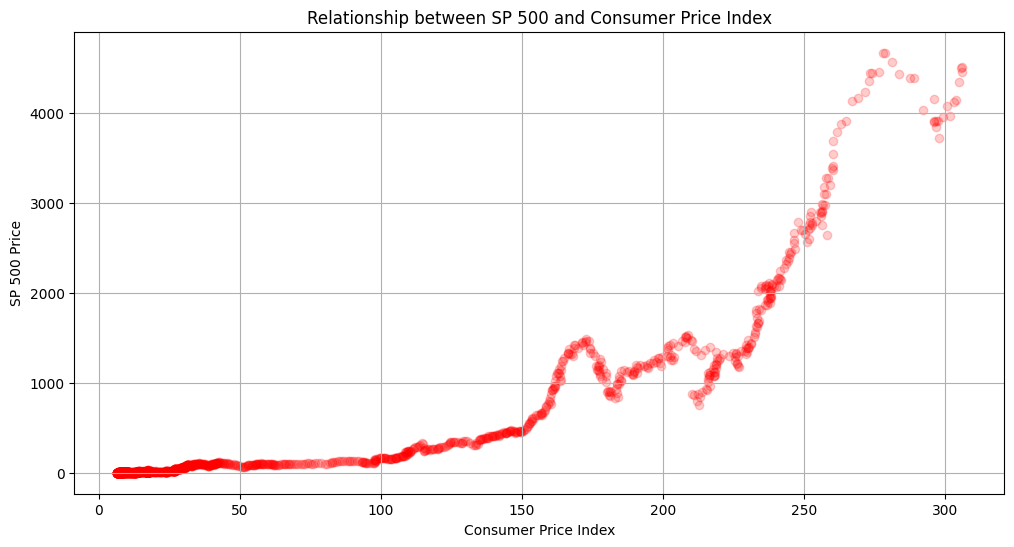

In [ ]:
#5
#Visualizing between SP500 and CPI
import matplotlib.pyplot as plt

print("Visualization of SP500 vs. Consumer Price Index:")
plt.figure(figsize=(12, 6))
plt.scatter(df['Consumer Price Index'], df['SP500'], alpha=0.2,color='red')
plt.title('Relationship between SP 500 and Consumer Price Index')
plt.xlabel('Consumer Price Index')
plt.ylabel('SP 500 Price')
plt.grid()
plt.show()

# why we chose this scatter plot ?
# If we look at the dataset it is like a time series dataset but then we want to see the coorelation between consumer price index and sp500
# hence scatter plot becomes the optimal choice


# Task 2: Feature Engineering (15 points)

In [ ]:



# 1

# Create a new column by calculating the year-over-year percentage change of the consumer price
#  index. Then, identify and print the top 5 dates with the highest CPI rate change.
print("Year-over-year Percentage Change of CPI")
df['CPI_YoY_Change'] = df['Consumer Price Index'].pct_change(periods=12) * 100
print("Top 5 dates with the highest CPI rate change:")
print(df.nlargest(5, 'CPI_YoY_Change')[['Date', 'CPI_YoY_Change']])


Year-over-year Percentage Change of CPI
Top 5 dates with the highest CPI rate change:
           Date  CPI_YoY_Change
593  1920-06-01       23.668639
592  1920-05-01       21.893491
110  1880-03-01       21.859903
591  1920-04-01       21.556886
574  1918-11-01       20.740741


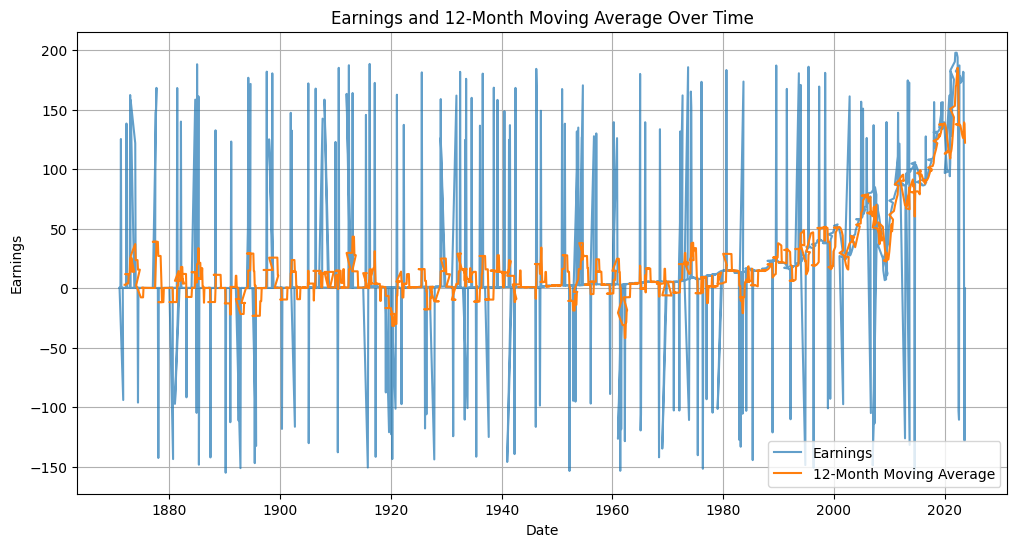

In [ ]:

# 2.Create a new column for the 12-month moving average of the Earnings columns and plot it with
#  Matplotlib. Explain your strategy to deal with first 12 months data

df['Earnings_MA'] = df['Earnings'].rolling(window=12).mean()
plt.figure(figsize=(12, 6))
plt.plot(pd.to_datetime(df['Date']), df['Earnings'], label='Earnings', alpha=0.7)
plt.plot(pd.to_datetime(df['Date']), df['Earnings_MA'], label='12-Month Moving Average')
plt.title('Earnings and 12-Month Moving Average Over Time')
plt.xlabel('Date')
plt.ylabel('Earnings')
plt.legend()
plt.grid(True)
plt.show()
#





In [ ]:
# 3 Normalize SP500 using Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['SP500_Normalized'] = scaler.fit_transform(df[['SP500']])
print("Top 10 dates with the highest normalized SP500 price:")
print(df.nlargest(10, 'SP500_Normalized')[['Date', 'SP500_Normalized']])



Top 10 dates with the highest normalized SP500 price:
            Date  SP500_Normalized
1811  2021-12-01          1.000000
1810  2021-11-01          0.998419
1812  2022-01-01          0.978391
1832  2023-09-01          0.965967
1830  2023-07-01          0.964320
1809  2021-01-01          0.954182
1831  2023-08-01          0.953465
1807  2021-08-01          0.952790
1808  2021-09-01          0.950936
1813  2022-02-01          0.948889


# `Task 3`Data Visualization

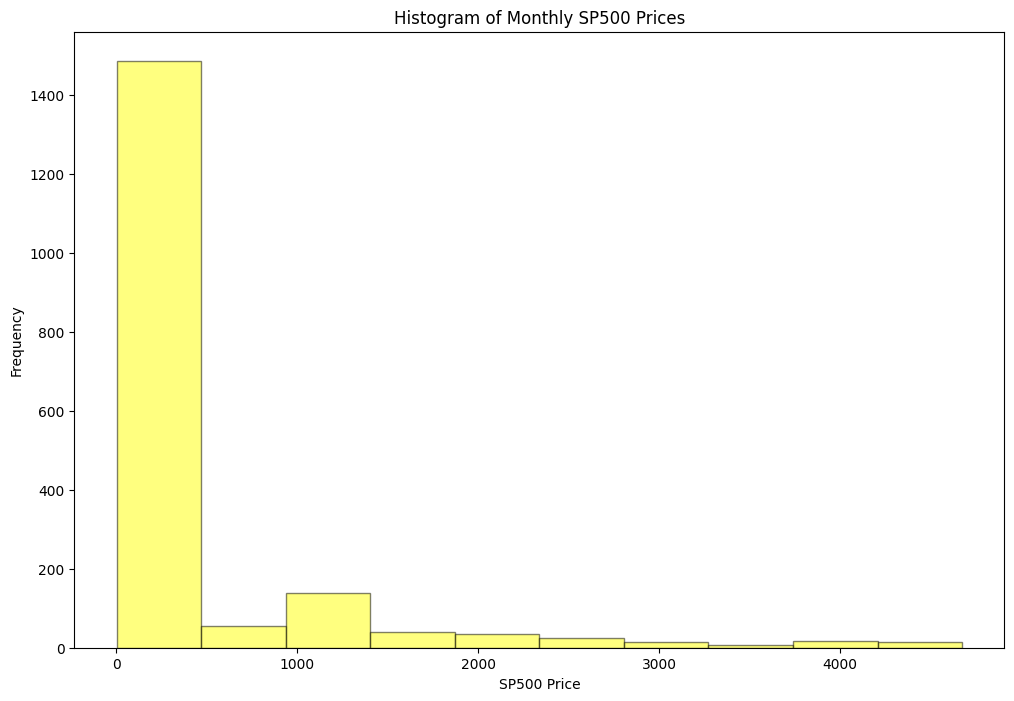

In [ ]:



# 1. Histogram of monthly SP500
plt.figure(figsize=(12, 8))
plt.hist(df['SP500'], bins=10, edgecolor='black', alpha=0.5,color='yellow')
plt.title('Histogram of Monthly SP500 Prices')
plt.xlabel('SP500 Price')
plt.ylabel('Frequency')

plt.show()



 Boxplot of PE10 column:


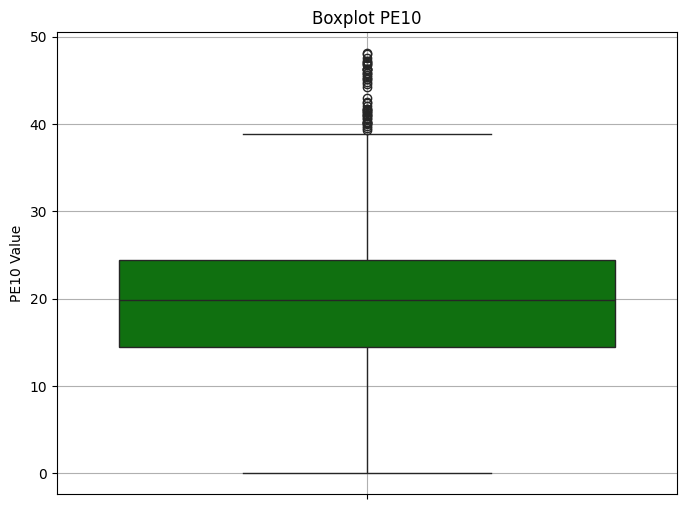

In [ ]:
#2 Boxplot PE10 column
import seaborn as sns

print("\n Boxplot of PE10 column:")
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['PE10'],color='green')
plt.title('Boxplot PE10')
plt.ylabel('PE10 Value')
plt.grid(True)
plt.show()




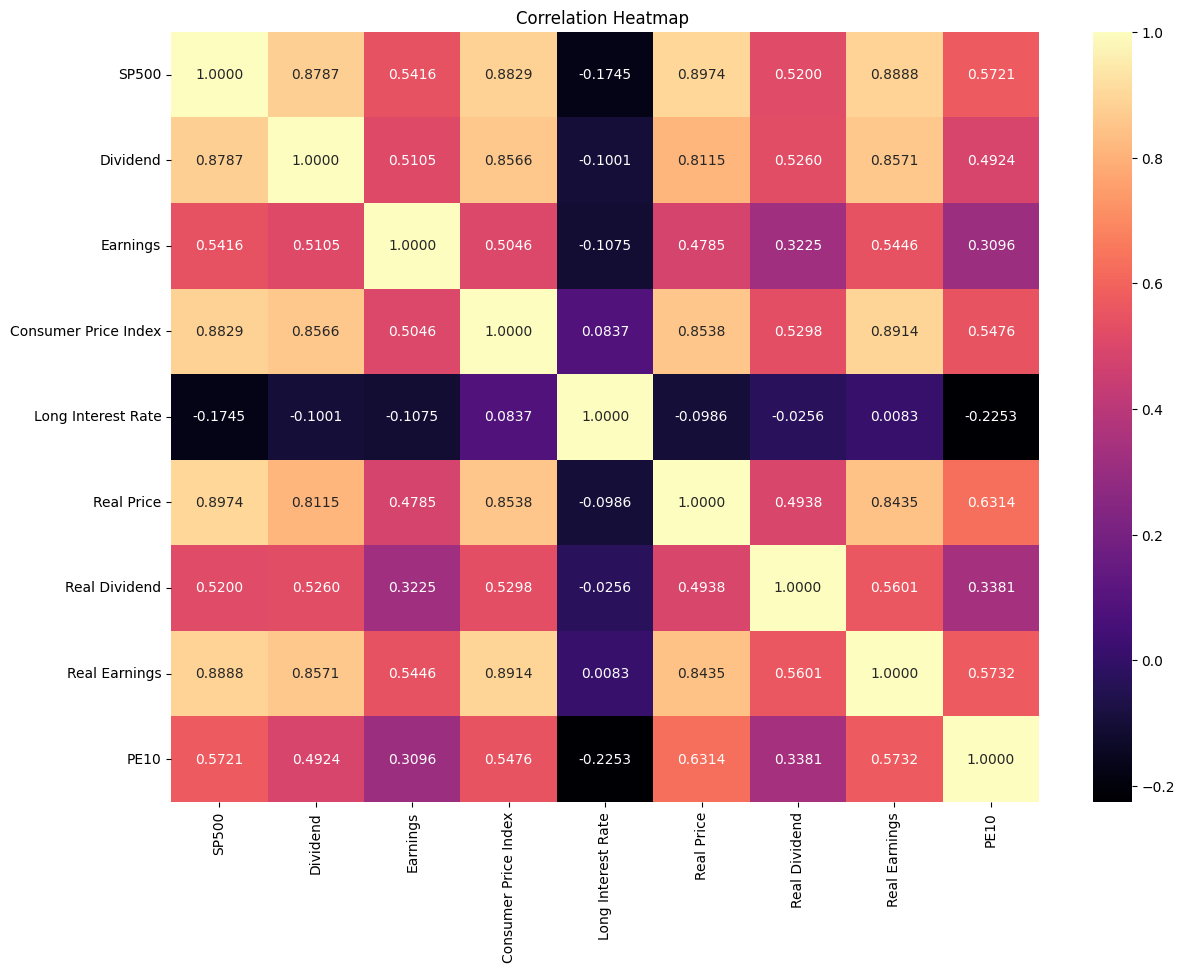

In [ ]:
#3 heatmap coorelation numerical features

numerical_features_corr = ['SP500', 'Dividend', 'Earnings', 'Consumer Price Index', 'Long Interest Rate',
                           'Real Price', 'Real Dividend', 'Real Earnings', 'PE10']
correlation_matrix = df[numerical_features_corr].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='magma', fmt=".4f")
plt.title('Correlation Heatmap ')
plt.show()

# Part 2: Machine **Learning**

# Task 1: Clustering with KMeans (20 points)

In [ ]:

#  1. Select all the numerical features for clustering (eg: SP500, Dividend, Earnings, Consumer Price
#  Index, Long Interest Rate, Real Price, Real Dividend, Real Earnings, PE10)


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

numerical_features = ['SP500', 'Dividend', 'Earnings', 'Consumer Price Index', 'Long Interest Rate', 'Real Price', 'Real Dividend', 'Real Earnings', 'PE10']
X = df[numerical_features].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

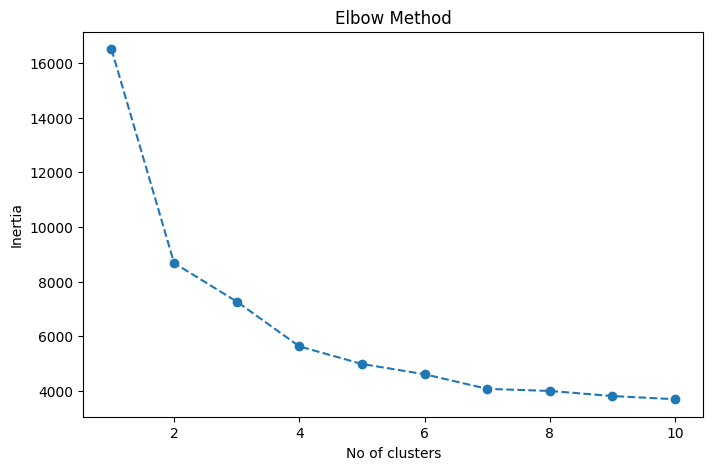

In [ ]:

#2. Determine the optimal number of clusters using the elbow method.
inertia = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=30)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, 'o--')
plt.xlabel('No of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

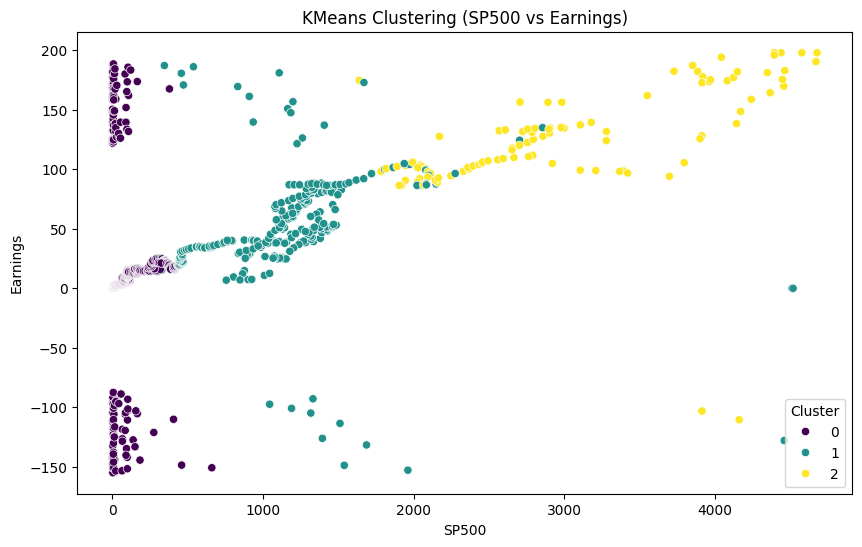

In [ ]:
#  3. Apply KMeans clustering and visualize the resulting clusters using a scatter plot.
# Apply KMeans with chosen k (example k=3)
kmeans = KMeans(n_clusters=3, random_state=30)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# SP500 vs Earnings
plt.figure(figsize=(10,6))
sns.scatterplot(x='SP500', y='Earnings', hue='Cluster', data=df, palette='viridis')
plt.xlabel('SP500')
plt.ylabel('Earnings')
plt.title('KMeans Clustering (SP500 vs Earnings)')
plt.show()

# 4. Describe the details of the clustering, discuss the clustering results.



Features We used:

We selected numerical features such as SP500, Dividend, Earnings, CPI, Long Interest Rate, Real Price, Real Dividend, Real Earnings, PE10.

Before forming clusters we scaled the features using StandardScaler inorder to normalize values.

Choosing No of Clusters:

The Elbow Method was used: plotting inertia (sum of squares within the clusters) against number of clusters(k).

The elbow point (where inertia slow downs) was suggested which is 3

KMeans Model:

KMeans was applied with the chosen cluster of 3.

Each data point of a month in the dataset was assigned a cluster label.

**Discussion of Results**


*   Cluster 0 (Purple): it contains companies with both high positive and high negative earnings but generally lower SP500 values. They are located at far left of  plot.

*  Cluster 1 (Green): this cluster has a group of companies with a wide range of SP500 values and earnings there is a also a trend of higher earnings as SP500 values increases it is in the middle of the plot.
* Cluster 2 (Yellow): This cluster consists of companies with highest SP500 values with positive earnings, the representation is on this cluster is from middle to far right.











In [ ]:
# Task 2 Machine Learning Models
#1
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, accuracy_score

# drop null columns
X_reg = df[numerical_features].dropna()
y_reg = df['SP500'].loc[X_reg.index]
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=35)


lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print('Linear Regression RMSE:', rmse)

Linear Regression RMSE: 2.9667716249082905e-13


In [ ]:
#2
# CPI Trend Classification (Up/Down)
df['CPI_trend'] = (df['Consumer Price Index'].diff() > 0).astype(int)
X_cls = X_reg
y_cls = df['CPI_trend'].loc[X_cls.index]
X_train, X_test, y_train, y_test = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('CPI Trend Classification Accuracy:', accuracy_score(y_test, y_pred))

CPI Trend Classification Accuracy: 0.7002724795640327


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df['CPI_Next'] = df['Consumer Price Index'].shift(-1)
df['CPI_Trend'] = (df['CPI_Next'] > df['Consumer Price Index']).astype(int)


df_class = df.dropna(subset=numerical_features + ['CPI_Trend'])

X = df_class[numerical_features]  # all numerical features
y = df_class['CPI_Trend']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.7057220708446866

Confusion Matrix:
 [[137  36]
 [ 72 122]]

Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.79      0.72       173
           1       0.77      0.63      0.69       194

    accuracy                           0.71       367
   macro avg       0.71      0.71      0.71       367
weighted avg       0.72      0.71      0.70       367

